# Setup Environment

In [1]:
# Install necessary libraries using magic command
%pip install --break-system-packages -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries

# pyright: reportMissingImports=false

# Standard libraries
import os
import sys
import random
import json
from contextlib import contextmanager
from pathlib import Path

# TensorFlow and TensorFlow Datasets
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Other libraries
from tqdm.keras import TqdmCallback

# Check TensorFlow version and GPU availability
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Name:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.17.0
Num GPUs Available: 1
GPU Name: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1787734170.953980     158 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787734171.456088     158 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787734171.456127     158 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# Set random seeds for reproducibility

# os.environ['TF_DETERMINISTIC_OPS'] = '1'    # Ensure deterministic operations in TensorFlow

# Define the seed for various libraries to ensure reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [4]:
# Create dictory for plots and models

plots_dir      = Path('./plots')
eda_plots_dir  = plots_dir / 'eda'
eval_plots_dir = plots_dir / 'evaluation'

results_dir = Path('./results')
models_dir  = Path('./models')

plots_dir.mkdir(parents=True, exist_ok=True)
eda_plots_dir.mkdir(parents=True, exist_ok=True)
eval_plots_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Collection

In [10]:
# Load the Stanford Dogs dataset using TensorFlow Datasets (TFDS)

# 80% Train, 20% Val from the original train split, plus untouched Test
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'stanford_dogs',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True,
    data_dir='./data',
    try_gcs=True        # Use Google Cloud Storage if available for faster download
)

print(f"Train samples: {len(ds_train)}")  # 9,600 images
print(f"Val samples:   {len(ds_val)}")    # 2,400 images
print(f"Test samples:  {len(ds_test)}")   # 8,580 images

Train samples: 9600
Val samples:   2400
Test samples:  8580


# Exploratory Data Analysis

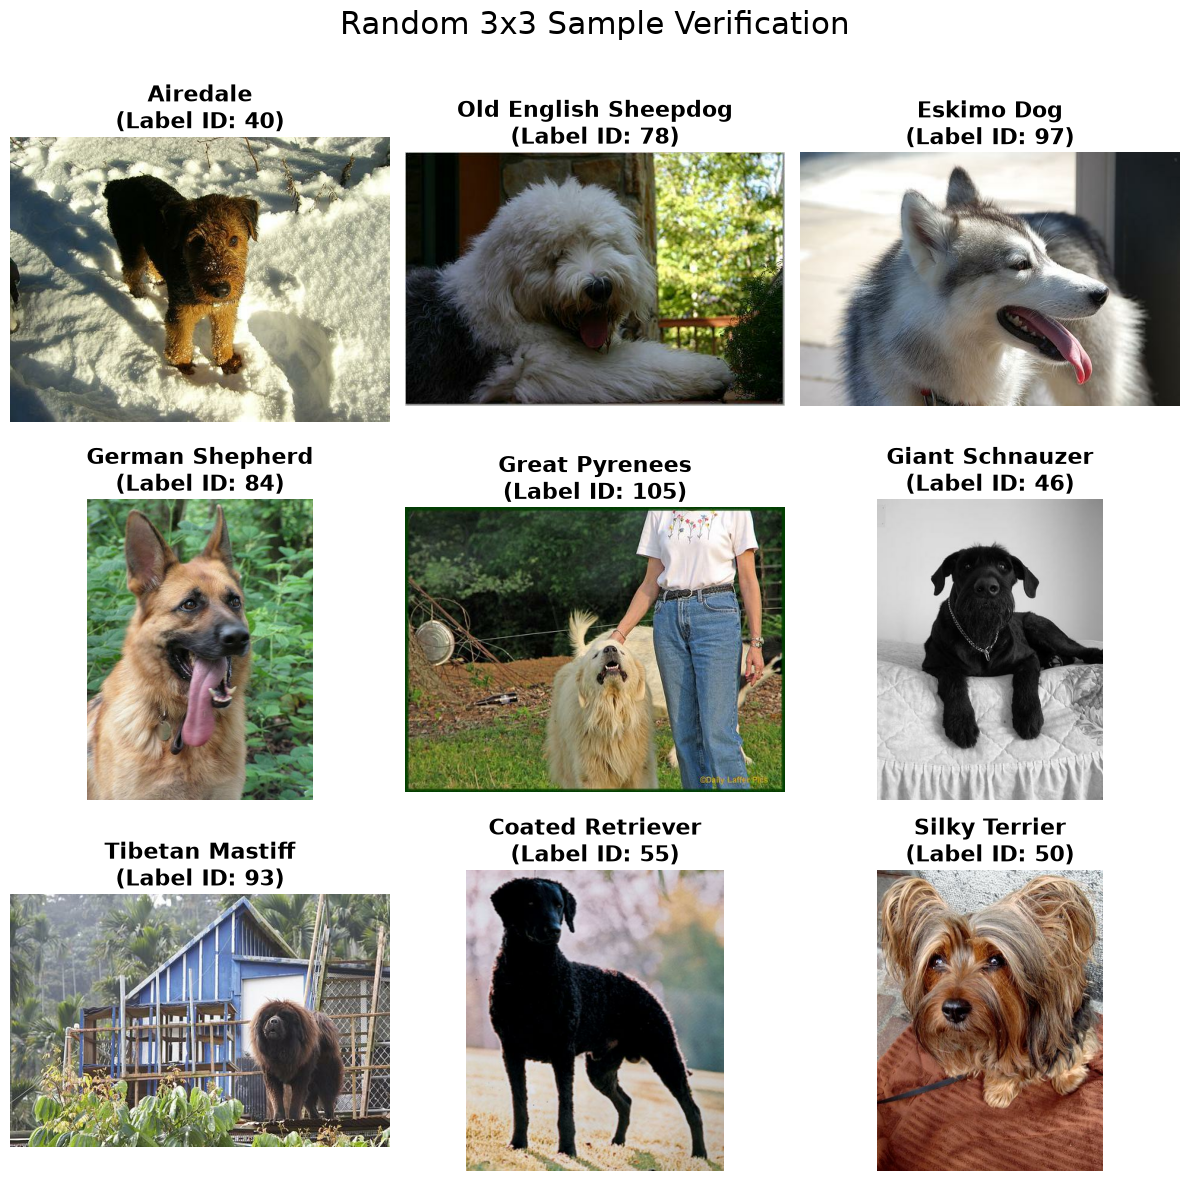

In [11]:
# 1. Visualize a random 3x3 sample of images from the training dataset

# Extract class names and clean them for better readability
# Name example: 'n02085620-Chihuahua' -> 'Chihuahua'
raw_names = ds_info.features['label'].names
clean_names = [name.split('-')[-1].replace('_', ' ').title() for name in raw_names]


plt.figure(figsize=(12, 12))

for i, (image, label) in enumerate(ds_train.shuffle(buffer_size=1000, seed=42).take(9)):
    ax = plt.subplot(3, 3, i + 1)
    
    # Convert the image tensor to a NumPy array and display it
    plt.imshow(image.numpy().astype("uint8"))
    
    # Get the corresponding breed name
    label_idx = label.numpy()
    breed_name = clean_names[label_idx]
    
    plt.title(f"{breed_name}\n(Label ID: {label_idx})", fontsize=16, fontweight='bold')
    plt.axis("off")

plt.suptitle("Random 3x3 Sample Verification", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(eda_plots_dir / '01_random_sample_verification.png', dpi=300)
plt.show()

Min images per breed: 70
Max images per breed: 163
Mean images per breed: 80.67


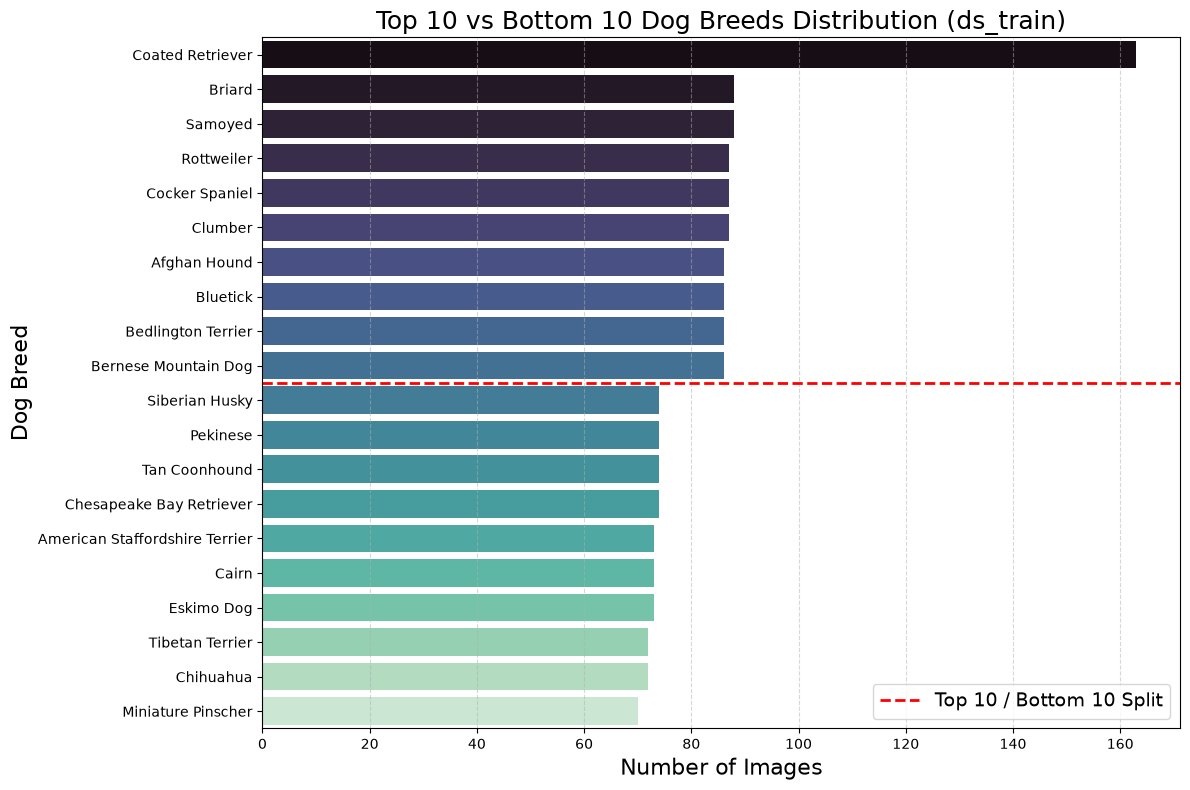

In [7]:
# 2. Class Distribution Bar Chart

# Create a dataset of labels only from the training dataset
labels_ds = ds_train.map(lambda img, label: label)

# Extract all labels from the dataset
train_labels = []
for label_batch in labels_ds.batch(1024):
    train_labels.extend(label_batch.numpy())

# Create a DataFrame to count the occurrences of each breed
df_classes = pd.DataFrame({'Breed': [clean_names[i] for i in train_labels]})
class_counts = df_classes['Breed'].value_counts().reset_index()
class_counts.columns = ['Breed', 'Count']


# Print the min max and mean of the class counts
print(f"Min images per breed: {class_counts['Count'].min()}")
print(f"Max images per breed: {class_counts['Count'].max()}")
print(f"Mean images per breed: {class_counts['Count'].mean():.2f}")


# plot the top 10 and bottom 10 dog breeds based on the number of images in the training dataset
plt.figure(figsize=(12, 8))
top_bottom = pd.concat([class_counts.head(10), class_counts.tail(10)])
sns.barplot(data=top_bottom, y='Breed', x='Count', hue='Breed', palette='mako', legend=False)

# Add a horizontal line to separate the top and bottom breeds
plt.axhline(y=9.5, color='red', linestyle='--', linewidth=2, label='Top 10 / Bottom 10 Split')

plt.title('Top 10 vs Bottom 10 Dog Breeds Distribution (ds_train)', fontsize=18)
plt.xlabel('Number of Images', fontsize=16)
plt.ylabel('Dog Breed', fontsize=16)
plt.legend(loc='lower right', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / '02_breeds_distribution.png', dpi=300)
plt.show()

In [8]:
# Optional: Visualize the distribution of all 120 dog breeds

# plt.figure(figsize=(10, 24))
# sns.barplot(data=class_counts, y='Breed', x='Count', hue='Breed', palette='viridis', legend=False)
# plt.title('All 120 Dog Breeds Distribution', fontsize=14)
# plt.xlabel('Number of Images')
# plt.ylabel('Dog Breed')
# plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

Min Dimension: 100 x 103
Max Dimension: 2740 x 2560
Mean Dimension: 444 x 388


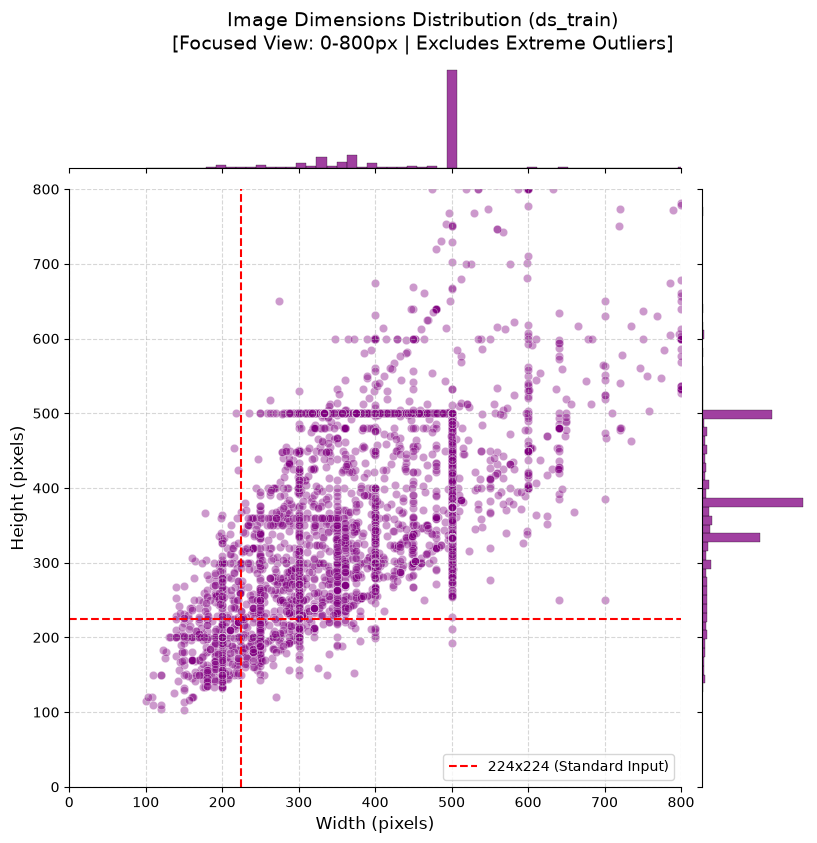

In [12]:
# 3. Image Dimension Scatter Plot

# Extract the width and height of all images in the training dataset
widths = []
heights = []
for img, _ in ds_train:
    shape = img.shape
    heights.append(shape[0])
    widths.append(shape[1])

# Print the min, max, and mean dimensions of the images
print(f"Min Dimension: {min(widths)} x {min(heights)}")
print(f"Max Dimension: {max(widths)} x {max(heights)}")
print(f"Mean Dimension: {int(np.mean(widths))} x {int(np.mean(heights))}")

# plot the scatter plot of image dimensions
g = sns.jointplot(
    x=widths, 
    y=heights, 
    kind='scatter', 
    alpha=0.4, 
    color='purple',
    height=8
)

# Mark common pre-trained model input sizes
g.ax_joint.axvline(224, color='red', linestyle='--', label='224x224 (Standard Input)')
g.ax_joint.axhline(224, color='red', linestyle='--')
g.ax_joint.legend()

# Set the x and y limits to focus on the majority of the data, excluding extreme outliers
g.ax_joint.set_xlim(0, 800)
g.ax_joint.set_ylim(0, 800)
g.set_axis_labels('Width (pixels)', 'Height (pixels)', fontsize=12)

# Set the title and adjust layout
g.fig.suptitle('Image Dimensions Distribution (ds_train)\n[Focused View: 0-800px | Excludes Extreme Outliers]', y=1.02, fontsize=14)
g.fig.subplots_adjust(top=0.95)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(eda_plots_dir / '03_image_dimensions_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Stage 1 : Feature Extraction